# Fasttext tests

Based on https://github.com/BarbaraMcG/latinise/blob/83e9efdd6a216f16d89b4a181a6771c93436549f/lvlt22/Semantic_change.ipynb 

Compares embeddings for 4 different time slices (early and classical; post-classical; medieval; neo-latin)

## Packages

In [1]:
import os 
import csv
import numpy as np
import pandas as pd
from gensim.models import FastText
import gensim
from scipy import spatial
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import time
from sklearn.decomposition import PCA

import plotly.express as px
import re
from statistics import mean
# to make our plot outputs appear and be stored within the notebook:
%matplotlib inline 

## Read the files

Find folder with corpus in directory:

In [2]:
dir_in = os.getcwd()
print(dir_in)

/Users/valentinalunardi/Documents/GitHub/latinise/neolatin


Define path to output folder:

In [3]:
dir_out = os.path.join(dir_in, "fasttext_output")

Define files and count them (the lemmas and tokens are grouped by text, so the number reflects the number of texts):

In [4]:
files = os.listdir(os.path.join(dir_in, "new_lemmatized_texts"))
len(files)

1247

Use IntraText and Musisque Deoque texts in LatinISE (no LacusCurtius yet):

In [5]:
files = [f for f in files[:] if ("IT" in f or "MQDQ" in f)]
len(files)

1232

Read the metadata file:

In [6]:
metadata_df = pd.read_csv(os.path.join(dir_in, 'latinise_metadata_2024.csv'), sep = ",")
metadata_df = metadata_df[metadata_df['id'].str.startswith(("IT", "MQDQ"))]
metadata_df

,id,title,creator,date,type,file,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10,Unnamed: 11
0,IT-LAT0261,Carmen Saliare,[Auctor incertus],-650,poetry,lat_0350_IT-LAT0261.txt,NaN,NaN,NaN,NaN,NaN,NaN
1,IT-LAT0285,XII Tabularum Leges,[Auctor incertus],-450,prose,lat_-0450_IT-LAT0285.txt,NaN,NaN,NaN,NaN,NaN,NaN
2,IT-LAT0262,Carmen Arvale,[Auctor incertus],-350,poetry,lat_0350_IT-LAT0262.txt,NaN,NaN,NaN,NaN,NaN,NaN
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt,NaN,NaN,NaN,NaN,NaN,NaN
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
1241,IT-LAT0446,Sacramentorum sanctitatis tutela,Ioannes Paulus PP. II,2002,prose,lat_2002_IT-LAT0446.txt,NaN,NaN,NaN,NaN,NaN,NaN
1242,IT-LAT0536,Misericordia Dei,Ioannes Paulus PP. II,2002,prose,lat_2002_IT-LAT0536.txt,NaN,NaN,NaN,NaN,NaN,NaN
1243,IT-LAT0762,Ecclesia de Eucharistia,Ioannes Paulus PP. II,2003,prose,lat_2003_IT-LAT0762.txt,NaN,NaN,NaN,NaN,NaN,NaN
1244,IT-LAT0839,Instructio Redemptionis Sacramentum,Congregatio de Cultu Divino et Disciplina Sacr...,2004,prose,lat_2004_IT-LAT0839.txt,NaN,NaN,NaN,NaN,NaN,NaN


Drop NaN columns:

In [7]:
metadata_df.drop(columns=['Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Unnamed: 9', 'Unnamed: 10', 'Unnamed: 11'], inplace=True)

# Verify the changes
metadata_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1232 entries, 0 to 1245
Data columns (total 6 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   id       1232 non-null   object
 1   title    1232 non-null   object
 2   creator  1232 non-null   object
 3   date     1232 non-null   int64 
 4   type     1232 non-null   object
 5   file     1232 non-null   object
dtypes: int64(1), object(5)
memory usage: 67.4+ KB


Convert date to integer:

In [8]:
metadata_df['date'] = metadata_df['date'].astype(int)
metadata_df.dtypes

id         object
title      object
creator    object
date        int64
type       object
file       object
dtype: object

Show number of works per year:

In [9]:
metadata_df0 = metadata_df.groupby(['date']).count()
metadata_df0 = metadata_df0['id']
metadata_df0

date
-650     1
-450     1
-350     1
-290     1
-229     1
        ..
 2001    4
 2002    2
 2003    1
 2004    1
 2005    1
Name: id, Length: 379, dtype: int64

## Define time intervals

Find the first and last date in dataset:

In [10]:
first_date = min(metadata_df.date)
last_date = max(metadata_df.date)
print(first_date)
print(last_date)

-650
2005


Create intervals according to IntraText time slices (Latinitas Romana, Mediaevalis, Nova):

In [11]:
first_date = min(metadata_df.date)
second_date = 149
third_date = 499
fourth_date = 1399
last_date = max(metadata_df.date)

intervals = [first_date, second_date + 1, third_date + 1, fourth_date + 1, last_date +1]
n_intervals = 4

print("intervals:", intervals)
print("n_intervals:", n_intervals)

intervals: [-650, 150, 500, 1400, 2006]
n_intervals: 4


Add a column to metadata_df for the time interval:

In [12]:
metadata_df['time_interval'] = ""
for t in range(len(intervals)-1):
    print(t)
    print(range(intervals[t],intervals[t+1]))
    metadata_df_t = metadata_df.loc[metadata_df['date'].isin(range(intervals[t],intervals[t+1]))]
    print(metadata_df_t['date'])
    metadata_df.loc[metadata_df['date'].isin(range(intervals[t],intervals[t+1])),'time_interval'] = intervals[t]
metadata_df

0
range(-650, 150)
0     -650
1     -450
2     -350
3     -290
4     -229
      ... 
415    116
416    116
417    121
418    147
419    147
Name: date, Length: 417, dtype: int64
1
range(150, 500)
420    150
421    150
422    150
423    150
424    150
      ... 
798    450
799    450
800    458
801    458
802    473
Name: date, Length: 373, dtype: int64
2
range(500, 1400)
803      500
804      500
805      502
806      514
807      518
        ... 
1097    1350
1098    1350
1099    1355
1100    1360
1101    1397
Name: date, Length: 298, dtype: int64
3
range(1400, 2006)
1102    1410
1103    1428
1104    1434
1105    1434
1106    1434
        ... 
1241    2002
1242    2002
1243    2003
1244    2004
1245    2005
Name: date, Length: 144, dtype: int64


,id,title,creator,date,type,file,time_interval
0,IT-LAT0261,Carmen Saliare,[Auctor incertus],-650,poetry,lat_0350_IT-LAT0261.txt,-650
1,IT-LAT0285,XII Tabularum Leges,[Auctor incertus],-450,prose,lat_-0450_IT-LAT0285.txt,-650
2,IT-LAT0262,Carmen Arvale,[Auctor incertus],-350,poetry,lat_0350_IT-LAT0262.txt,-650
3,MQDQ-288,carminum fragmenta,"Caecus, Appius Claudius",-290,poetry,lat_-0300_MQDQ-288.txt,-650
4,IT-LAT1006,Praecepta,"Marcius Vates, Gnaeus",-229,prose,lat_-0229_IT-LAT1006.txt,-650
...,...,...,...,...,...,...,...
1241,IT-LAT0446,Sacramentorum sanctitatis tutela,Ioannes Paulus PP. II,2002,prose,lat_2002_IT-LAT0446.txt,1400
1242,IT-LAT0536,Misericordia Dei,Ioannes Paulus PP. II,2002,prose,lat_2002_IT-LAT0536.txt,1400
1243,IT-LAT0762,Ecclesia de Eucharistia,Ioannes Paulus PP. II,2003,prose,lat_2003_IT-LAT0762.txt,1400
1244,IT-LAT0839,Instructio Redemptionis Sacramentum,Congregatio de Cultu Divino et Disciplina Sacr...,2004,prose,lat_2004_IT-LAT0839.txt,1400


Visualise distribution of time intervals:

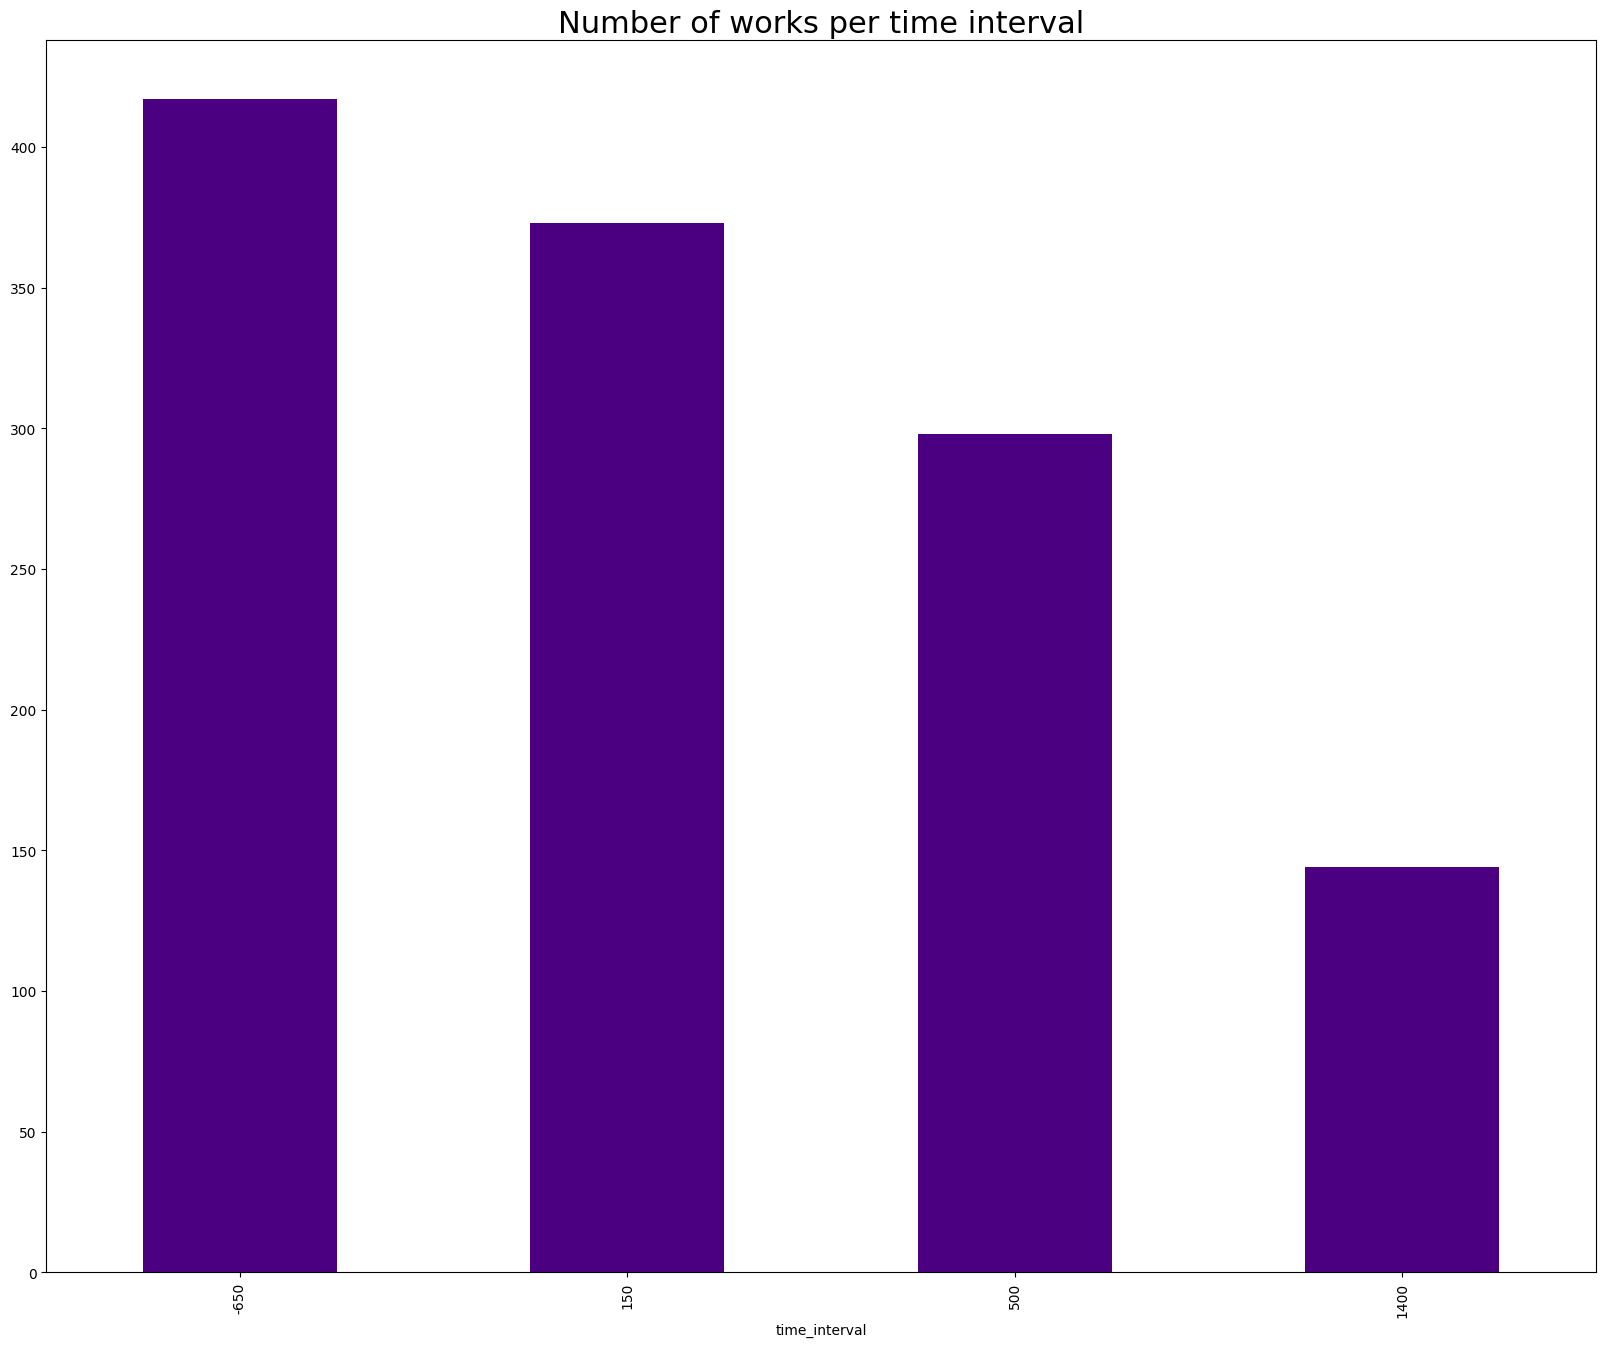

In [13]:
metadata_df0 = metadata_df.groupby(['time_interval']).count()
metadata_df0 = metadata_df0['id']
metadata_df0
ax = metadata_df0.plot(kind='bar', figsize=(20,16), color="indigo", fontsize=10);
ax.set_title("Number of works per time interval", fontsize=22)
plt.show()

## Train embeddings for whole corpus

Function for printing the vocabulary of a model:

In [14]:
def print_vocab(model, top_n = None):
  if model == '':
    print("Empty model!")
  else:
    count = 0
    if top_n is not None:
      for index, word in enumerate(model.wv.index_to_key):
        count+= 1
        if count < top_n:
          print(f"word #{index}/{len(model.wv.index_to_key)} is {word}")
    else:
      for index, word in enumerate(model.wv.index_to_key):
        print(f"word #{index}/{len(model.wv.index_to_key)} is {word}")

Function that converts dates into the standard format:

In [15]:
def convert_dates(sign, date0):

    if sign == "0":
        if date0 == 0:
            final_date = "+0000"
        elif date0 < 100:
            final_date = "+" + "00" + str(date0)
            #print("1-final_date", final_date)
        elif date0 < 1000:
            final_date = "+" + "0" + str(date0)
            #print("2-final_date", final_date)
        else:
            final_date = "+" + str(date0)
            #print("3-final_date", final_date)
    else:
        if date0 == 0:
            final_date = "+0000"
        elif date0 < 100:
            final_date = str(sign) + "00" + str(date0)
            #print("1-final_date", final_date)
        elif date0 < 1000:
            final_date = str(sign) + "0" + str(date0)
            #print("2-final_date", final_date)
        else:
            final_date = str(sign) + str(date0)
            #print("3-final_date", final_date)

    if final_date.startswith("+"):
        final_date = final_date.replace("+", "")
    return final_date

### Stopwords exclusion and further filtering

Exclude punctuation marks:

In [17]:
punctuation = ['.', ',', '...', ';', ':', '?', '(', ')', '-', '!', '[', ']', '"', "'", '""', '\n', '']

### Make corpus

Create a list of lists, containing the (lemmatized) tokens of each sentence in the whole corpus (excluding punctuation):

In [18]:
corpus = list()
files_corpus = metadata_df
for index, df_line in files_corpus.iterrows():
    #print("line:",df_line['id'], df_line['time_interval'])
    sign = "+"
    #print(df_line['date'])
    if df_line['date'] < 0:
        sign = "-"
    #print("date:", convert_dates(sign, abs(df_line['date'])))
    file_name = df_line['file']#'lat_'+str(convert_dates(sign, abs(df_line['date'])))+"_"+str(df_line['id'])+'.txt'
    print("3:",file_name)
    file = open(os.path.join(dir_in, "new_lemmatized_texts", file_name), 'r')
    #sentences_this_file = list()
    while True:
        line = file.readline().strip()
        if line != "":
            #sentences_this_file.append(line.split(" "))
            #sentences_this_file.append([token for token in line.split(" ") if token not in punctuation])
            corpus.append([token for token in line.split(" ") if token not in punctuation])
        # if line is empty end of file is reached
        if not line:
            break
    file.close()
#corpus.append(sentences_this_file)

3: lat_0350_IT-LAT0261.txt
3: lat_-0450_IT-LAT0285.txt
3: lat_0350_IT-LAT0262.txt
3: lat_-0300_MQDQ-288.txt
3: lat_-0229_IT-LAT1006.txt
3: lat_-0255_MQDQ-237.txt
3: lat_-0243_MQDQ-168.txt
3: lat_-0243_MQDQ-169.txt
3: lat_-0243_MQDQ-167.txt
3: lat_-0234_MQDQ-228.txt
3: lat_-0234_MQDQ-230.txt
3: lat_-0234_MQDQ-229.txt
3: lat_-0234_MQDQ-227.txt
3: lat_-0234_MQDQ-226.txt
3: lat_-0203_MQDQ-74.txt
3: lat_-0203_MQDQ-73.txt
3: lat_-0203_MQDQ-70.txt
3: lat_-0203_MQDQ-72.txt
3: lat_-0203_MQDQ-71.txt
3: lat_-0218_MQDQ-323.txt
3: lat_-0149.0_MQDQ-164.txt
3: lat_-0218_MQDQ-306.txt
3: lat_-0218_MQDQ-307.txt
3: lat_-0218_MQDQ-308.txt
3: lat_-0218_MQDQ-309.txt
3: lat_-0218_MQDQ-310.txt
3: lat_-0218_MQDQ-311.txt
3: lat_-0218_MQDQ-312.txt
3: lat_-0218_MQDQ-313.txt
3: lat_-0218_MQDQ-314.txt
3: lat_-0218_MQDQ-327.txt
3: lat_-0218_MQDQ-315.txt
3: lat_-0218_MQDQ-316.txt
3: lat_-0218_MQDQ-317.txt
3: lat_-0218_MQDQ-318.txt
3: lat_-0218_MQDQ-319.txt
3: lat_-0218_MQDQ-322.txt
3: lat_-0218_MQDQ-324.txt
3: lat_-0

Show the corpus:

In [19]:
corpus

[['diuus',
  'emo',
  'cano',
  'diuus',
  'deus',
  'supplico',
  'cuma',
  'tono',
  'Leucesia',
  'prae',
  'tet',
  'tremoo',
  'quot',
  'ibo',
  'etinei',
  'de',
  'hic',
  'cum',
  'tono',
  'coazeulodorieso'],
 ['omnis', 'uero', 'adpatula', 'coemitto'],
 ['si', 'in', 'ius', 'uoco', 'eo'],
 ['ni', 'eo', 'antestamino'],
 ['igitur', 'es', 'capitus'],
 ['si', 'caluor', 'pes', 'ue', 'struo', 'manus', 'o', 'iacio'],
 ['si', 'morbus', 'aevitasve', 'uitium', 'esco', 'iumentum', 'do'],
 ['si', 'nolo', 'arcer', 'ne', 'sterno'],
 ['assiduo', 'uindex', 'assiduus', 'sum'],
 ['proletarius', 'iam', 'ciuis', 'quis', 'uolo', 'uindex', 'sum'],
 ['nex', 'fortis', 'sano', 'res', 'ubi', 'paco', 'oro'],
 ['ni',
  'paco',
  'in',
  'comitio',
  'aut',
  'in',
  'forum',
  'ante',
  'meridies',
  'caussa',
  'coicio'],
 ['cum', 'peroro', 'ambo', 'praesens'],
 ['post', 'meridies', 'praesens', 'lis', 'addico'],
 ['si',
  'ambo',
  'praesens',
  'solus',
  'occasus',
  'supremus',
  'tempestas',
  'sum'

Count how many sentences in corpus:

In [20]:
len(corpus)

635735

### Train with FastText and play with parameters

Function for training FastText models (from Krzysztof Nowak):

In [21]:
def fasttext(self, opts=dict()):
        """
        Reads sentences from the corpus. Implements:
            https://radimrehurek.com/gensim/models/fasttext.html#gensim.models.fasttext.FastText
        Returns
        -------
        FastText model
        """
        default_opts = dict(vector_size=100, alpha=0.025,
                            window=5, min_count=5, epochs=5)
        opts_new = default_opts
        for opt in opts.keys():
            opts_new[opt] = opts[opt]
        model = FastText(
            vector_size=opts_new["vector_size"],
            alpha=opts_new["alpha"],
            window=opts_new["window"],
            min_count=opts_new["min_count"])
        model.build_vocab(corpus_iterable=[sentence for sentence in
                                           self.corpus.get_sents()])
        total_examples = model.corpus_count
        model.train(corpus_iterable=[sentence for sentence
                                     in self.corpus.get_sents()],
                    total_examples=total_examples,
                    epochs=opts_new["epochs"])
        return model

Parameters:

`min_count`: the minimum frequency threshold allowed for a word to be included; set to 3 following Ribary & McGillivray (2020) or 5 following Sprugnoli et al. (2019).

`vector_size`: the number of dimensions in which we wish to represent our word. This is the size of the word embedding; typically between 100 and 1,000. Set to 100 following Ribary & McGillivray (2020).

`window`: The size of the context window determines how many words before and after a given word would be included as context words of the given word. Typically between 5 and 10. Set to 10 following Sprugnoli et al. (2020).

`sg`: – Training algorithm: 1 for skip-gram; otherwise CBOW. 

WHAT? EPOCHS? Set to 10 following Ribary & McGillivray (2020).

QUESTIONS:
1) Is CBOW better than skip-gram?
2) Is this value for `alpha` (initial learning rate, i.e. how quickly weights are updated) good?

Train FastText embeddings and, for full reproducibility, limit the model to a single worker thread (workers=1), to eliminate ordering jitter from OS thread scheduling:

(`workers` restricts the training to a single CPU core – better for reproducibility, esp. with fixed random seed)

In [22]:
model = FastText(vector_size=100, alpha=0.025, window=5, min_count=50, workers=1, seed=1, hashfxn=hash)
model.build_vocab(corpus_iterable=corpus)
model.train(corpus_iterable=corpus, total_examples=model.corpus_count, epochs=5)

(41744952, 53888060)

Let's see what words are similar to "deus":

In [23]:
model.wv.similar_by_word('deus', 10)

[('Tydeus', 0.8542125821113586),
 ('Deus', 0.8262028098106384),
 ('spondeus', 0.6843377351760864),
 ('diuinitus', 0.6490842700004578),
 ('numen', 0.6434512734413147),
 ('diuinus', 0.6323542594909668),
 ('dea', 0.6124308705329895),
 ('lapideus', 0.6017476916313171),
 ('Christus', 0.5934435725212097),
 ('diuino', 0.5924625992774963)]

Let's try with different parameters:

In [ ]:
start = time.time()
model = FastText(vector_size=100, window=5, min_count=5, workers=1, seed=1, hashfxn=hash)
model.build_vocab(corpus_iterable=corpus)
model.train(corpus_iterable=corpus, total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 124 seconds


[('Tydeus', 0.8494255542755127),
 ('deu', 0.829310953617096),
 ('deuexa', 0.7631828188896179),
 ('Diomedeus', 0.7177985310554504),
 ('semideus', 0.7121793031692505),
 ('deuoti', 0.6763986945152283),
 ('Christus', 0.6665254831314087),
 ('deuexo', 0.6639180779457092),
 ('spondeus', 0.6568623781204224),
 ('lapideus', 0.6510533690452576)]

In [ ]:
start = time.time()
model = FastText(vector_size=100, window=10, min_count=5, workers=1, seed=1, hashfxn=hash)
model.build_vocab(corpus_iterable=corpus)
model.train(corpus_iterable=corpus, total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 191 seconds


[('Tydeus', 0.8613553643226624),
 ('deu', 0.8358835577964783),
 ('deuexa', 0.7643582820892334),
 ('semideus', 0.7424825429916382),
 ('Diomedeus', 0.7224067449569702),
 ('deuexo', 0.696245014667511),
 ('Christus', 0.6805629730224609),
 ('spondeus', 0.68006432056427),
 ('lapideus', 0.675530195236206),
 ('deuouet', 0.6542074084281921)]

The model has a vocabulary of

In [24]:
model.corpus_total_words

10777612

words and

In [25]:
model.corpus_count

635735

sentences.

Different configurations of the parameters for the embeddings against the gold standard set by Sprugnoli et al. (2019) (https://github.com/CIRCSE/Lemma-Embeddings-for-Latin/blob/master/syn-selection-benchmark-Latin.tsv) are evaluated to find the best configuration of parameters here: https://gitlab.surrey.ac.uk/mr0048/pydigest/-/blob/master/script/fasttext_003.py

## Train embeddings for each time interval

### Make corpora for time intervals

For each time interval, read the texts from files and create a list of lists, i.e. a list of sentences (excluding punctuation):

In [26]:
# dictionary that maps a time interval with the list of sentences of texts in that time interval"
time2corpus = dict()

# I loop over all time intervals:
for t in range(n_intervals+1):
    files_corpus_t = metadata_df.loc[metadata_df['time_interval'] == intervals[t]]
    #print("1:",files_corpus_t, type(files_corpus_t))
    corpus_t = list()
    for index, df_line in files_corpus_t.iterrows():
        #print("line:",df_line['id'], df_line['time_interval'])
        sign = "+"
        #print(df_line['date'])
        if df_line['date'] < 0:
            sign = "-"
        #print("date:", convert_dates(sign, abs(df_line['date'])))
        file_name = df_line['file']#'lat_'+str(convert_dates(sign, abs(df_line['date'])))+"_"+str(df_line['id'])+'.txt'
        #print("3:",file_name)
        file = open(os.path.join(dir_in, "new_lemmatized_texts", file_name), 'r')
        sentences_this_file = list()
        while True:
            line = file.readline().strip()
            if line != "":
                #sentences_this_file.append(line.split(" "))
                #sentences_this_file.append([token for token in line.split(" ") if token not in punctuation])
                corpus_t.append([token for token in line.split(" ") if token not in punctuation])
            # if line is empty end of file is reached
            if not line:
                break
        file.close()
        #corpus_t.append(sentences_this_file)
    #corpus_t1
    #print(len(corpus_t1[0]))
    time2corpus[t] = corpus_t

### Check if the two corpora have a similar amount of tokens

Show the subcorpus for the first time interval:

In [27]:
time2corpus[0]

[['diuus',
  'emo',
  'cano',
  'diuus',
  'deus',
  'supplico',
  'cuma',
  'tono',
  'Leucesia',
  'prae',
  'tet',
  'tremoo',
  'quot',
  'ibo',
  'etinei',
  'de',
  'hic',
  'cum',
  'tono',
  'coazeulodorieso'],
 ['omnis', 'uero', 'adpatula', 'coemitto'],
 ['si', 'in', 'ius', 'uoco', 'eo'],
 ['ni', 'eo', 'antestamino'],
 ['igitur', 'es', 'capitus'],
 ['si', 'caluor', 'pes', 'ue', 'struo', 'manus', 'o', 'iacio'],
 ['si', 'morbus', 'aevitasve', 'uitium', 'esco', 'iumentum', 'do'],
 ['si', 'nolo', 'arcer', 'ne', 'sterno'],
 ['assiduo', 'uindex', 'assiduus', 'sum'],
 ['proletarius', 'iam', 'ciuis', 'quis', 'uolo', 'uindex', 'sum'],
 ['nex', 'fortis', 'sano', 'res', 'ubi', 'paco', 'oro'],
 ['ni',
  'paco',
  'in',
  'comitio',
  'aut',
  'in',
  'forum',
  'ante',
  'meridies',
  'caussa',
  'coicio'],
 ['cum', 'peroro', 'ambo', 'praesens'],
 ['post', 'meridies', 'praesens', 'lis', 'addico'],
 ['si',
  'ambo',
  'praesens',
  'solus',
  'occasus',
  'supremus',
  'tempestas',
  'sum'

Count sentences for first time interval:

In [28]:
len(time2corpus[0])

204599

In [29]:
# Number of words
num_words_int_0 = sum(len(i) for i in time2corpus[0])
num_words_int_0

3705366

Show the subcorpus for the second time interval:

In [30]:
time2corpus[1]

[['cogito',
  'ego',
  'et',
  'cum',
  'animus',
  'meus',
  'Octavius',
  'bonus',
  'et',
  'fidelissimus',
  'contubernalis',
  'memoria',
  'recenseo',
  'tantus',
  'dulcedo',
  'et',
  'adfectio',
  'homo',
  'inhaereo',
  'ut',
  'ipse',
  'quodammodo',
  'ego',
  'uideo',
  'in',
  'praetereo',
  'redeo',
  'non',
  'is',
  'qui',
  'iam',
  'transigo',
  'et',
  'decurro',
  'sum',
  'recordatio',
  'reuoco',
  'ita',
  'is',
  'contemplatio',
  'quantum',
  'subtraho',
  'sum',
  'oculus',
  'tantum',
  'pectus',
  'meus',
  'atque',
  'paene',
  'intimus',
  'sensus',
  'implicatus',
  'sum'],
 ['neque',
  'inmerito',
  'discedo',
  'uir',
  'eximius',
  'et',
  'sanctus',
  'immensus',
  'suus',
  'desiderium',
  'nos',
  'relinquo',
  'utpote',
  'cum',
  'et',
  'ipse',
  'tantus',
  'noster',
  'semper',
  'amor',
  'flagravo',
  'ut',
  'et',
  'in',
  'ludicrus',
  'et',
  'seria',
  'par',
  'ego',
  'cum',
  'uoluntas',
  'concino',
  'idem',
  'uolo',
  'uel',
  'n

Count sentences for second time interval:

In [31]:
len(time2corpus[1])

121353

In [32]:
# Number of words
num_words_int_1 = sum(len(i) for i in time2corpus[1])
num_words_int_1

2204115

Show the subcorpus for the third time interval:

In [33]:
time2corpus[2]

[['flamen', 'sumo', 'samentum'],
 ['nihil',
  'cum',
  'fides',
  'graculum',
  'sum',
  'nihil',
  'cum',
  'amaracinus',
  'sui'],
 ['rex', 'sum', 'qui', 'recte', 'facio', 'qui', 'non', 'facio', 'non', 'sum'],
 ['habeo', 'scabies', 'quisquis', 'ad', 'ego', 'uenio', 'nouus'],
 ['malus', 'consilium', 'consultor', 'sum'],
 ['ibi', 'pastor', 'ludus', 'facio', 'corium', 'Consualis'],
 ['semel',
  'minusne',
  'an',
  'bis',
  'parum',
  'sum',
  'nescio',
  'an',
  'uterque',
  'is',
  'ut',
  'quondam',
  'audio',
  'dico',
  'Iuppiter',
  'ipse',
  'rex',
  'nolo',
  'concedo'],
 ['hibernus',
  'puluis',
  'vernus',
  'lutum',
  'grandis',
  'far',
  'camillus',
  'meto'],
 ['nouus',
  'uetus',
  'uinum',
  'bibo',
  'nouus',
  'uetus',
  'uinum',
  'morbus',
  'medeor'],
 ['pastor',
  'tu',
  'inuenio',
  'sine',
  'manus',
  'colligo',
  'sine',
  'focus',
  'coquo',
  'sine',
  'dens',
  'comedo'],
 ['neque',
  'mula',
  'pario',
  'neque',
  'lapis',
  'lana',
  'fero',
  'neque',
 

Count sentences for third time interval:

In [34]:
len(time2corpus[2])

203426

In [35]:
# Number of words
num_words_int_2 = sum(len(i) for i in time2corpus[2])
num_words_int_2

3225558

Count sentences for fourth time interval:

In [36]:
len(time2corpus[3])

106357

In [37]:
# Number of words in the second time interval
num_words_int_3 = sum(len(i) for i in time2corpus[3])
num_words_int_3

1642573

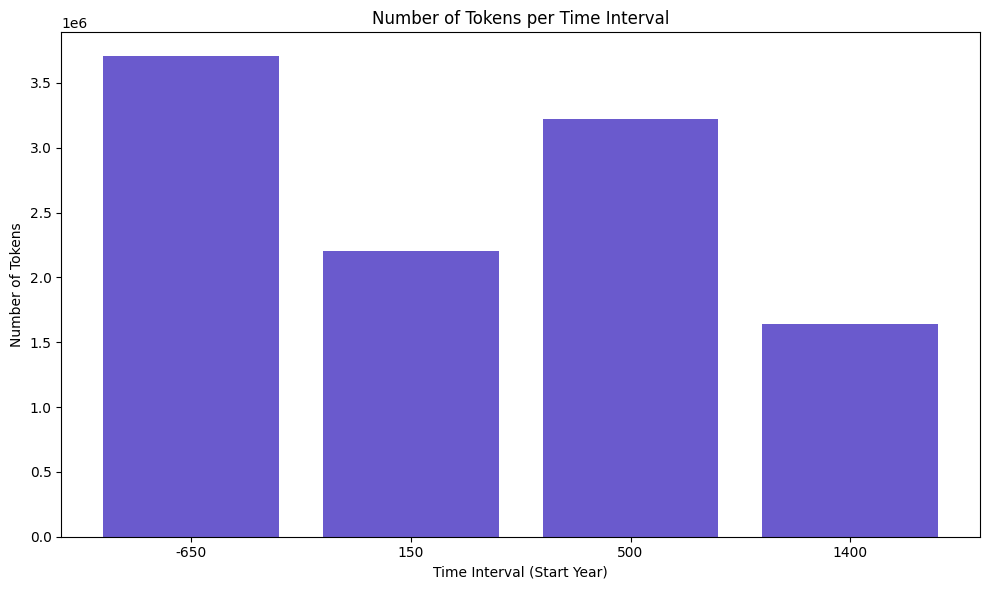

In [38]:
labels = ['-650', '150', '500', '1400']
counts = [num_words_int_0, num_words_int_1, num_words_int_2, num_words_int_3]

plt.figure(figsize=(10,6))
plt.bar(labels, counts, color='slateblue')
plt.xlabel('Time Interval (Start Year)')
plt.ylabel('Number of Tokens')
plt.title('Number of Tokens per Time Interval')
plt.tight_layout()
plt.show()

The intervals are not very balanced in terms of number of tokens.

### Train with FastText and play with parameters

Following the findings of Sprugnoli et al. (2019) and Ribary & McGillivray (2020), train a fasttext model for each time interval:

Train embeddings for the first time interval:

In [39]:
start = time.time()
model = FastText(vector_size=100, window=5, min_count=5, workers=1, seed=1,hashfxn=hash)
model.build_vocab(corpus_iterable=time2corpus[0])
model.train(corpus_iterable=time2corpus[0], total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

KeyboardInterrupt: 

In [ ]:
print_vocab(model, 10)

word #0/26628 is et
word #1/26628 is sum
word #2/26628 is qui
word #3/26628 is in
word #4/26628 is que
word #5/26628 is is
word #6/26628 is hic
word #7/26628 is non
word #8/26628 is ut


The corpus is small and the fasttext seems to prefer orthographic similarity with smaller min_counts. We're not interested in deus being similar to lapideus, but rather in deus being similar to divunus or immortalis. So, we have two options: we may either turn off the subwords or apply high frequency threshold (but we're going to lose low-frequency terms).

Try changing the parameters to exclude subwords (set `max_n` to 0):

In [46]:
start = time.time()
model = FastText(vector_size=100, window=5, min_count=5, workers=1, seed=1, hashfxn=hash, max_n=0) 
model.build_vocab(corpus_iterable=time2corpus[0])
model.train(corpus_iterable=time2corpus[0], total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 15 seconds


[('dus', 0.7730803489685059),
 ('dium', 0.7463822960853577),
 ('numen', 0.7208825945854187),
 ('Iuppiter', 0.7072937488555908),
 ('dea', 0.7067646980285645),
 ('diuus', 0.6738281846046448),
 ('superus', 0.6670135855674744),
 ('caelestis', 0.6353288292884827),
 ('precor', 0.5960894227027893),
 ('pius', 0.5795009136199951)]

In [47]:
model.wv.similar_by_word('pastor', 10)

[('stabulum', 0.8648497462272644),
 ('antrum', 0.7998631000518799),
 ('palus', 0.7928001284599304),
 ('armentum', 0.7906391620635986),
 ('lucus', 0.7865676879882812),
 ('lacus', 0.7833330631256104),
 ('stagnum', 0.7829194664955139),
 ('Ida', 0.7824474573135376),
 ('pastus', 0.7790549993515015),
 ('Triuia', 0.7777267098426819)]

Additionally, we could set a higher frequency threshold (set `min_count` to 50 rather than 5), but we would lose low-frequency terms:

In [42]:
start = time.time()
#model = gensim.models.Word2Vec(time2corpus[0], min_count=5, vector_size=100, window = 10, sg = 1)
start = time.time()
model = FastText(vector_size=100, window=10, min_count=50, workers=1, seed=1, hashfxn=hash, max_n=0) 
model.build_vocab(corpus_iterable=time2corpus[0])
model.train(corpus_iterable=time2corpus[0], total_examples=model.corpus_count, epochs=5)
end = time.time()
print("It has taken", round(end - start), "seconds")
model.wv.similar_by_word('deus', 10)

It has taken 14 seconds


[('dus', 0.7748650312423706),
 ('numen', 0.7188422679901123),
 ('dium', 0.6925686001777649),
 ('diuus', 0.6648777723312378),
 ('caelestis', 0.658029317855835),
 ('dea', 0.6289246678352356),
 ('superus', 0.6248795390129089),
 ('Iuppiter', 0.6169271469116211),
 ('diuinus', 0.584917426109314),
 ('ueneror', 0.580514132976532)]

In [45]:
model.wv.similar_by_word('pastor', 10)

[('stabulum', 0.8615279793739319),
 ('pascuum', 0.8361764550209045),
 ('lucus', 0.8051645755767822),
 ('armentum', 0.7973947525024414),
 ('lacus', 0.7958606481552124),
 ('nemus', 0.7884979844093323),
 ('auis', 0.7856076955795288),
 ('antrum', 0.7776298522949219),
 ('plaustrum', 0.7763001918792725),
 ('grex', 0.7746403813362122)]

Train embeddings for all time intervals (however many):

In [269]:
models = list()
start = time.time()
for t in range(len(time2corpus)):
    if len(time2corpus[t])>0:
        print(t)
        #model = gensim.models.Word2Vec(time2corpus[0][0], min_count=1, vector_size=300, window = 5, sg = 0)
        model = FastText(vector_size=100, window=5, min_count=10, workers=1, seed=1, hashfxn=hash, max_n=0)  # instantiate
        model.build_vocab(corpus_iterable=time2corpus[t])
        model.train(corpus_iterable=time2corpus[t], total_examples=len(time2corpus[t]), epochs=10)  # train
        models.append(model)
        #model = fasttext.train_unsupervised(time2corpus[0][0], model='skipgram')
end = time.time()
print("It has taken", round(end - start), "seconds, or ", round((end - start)/60), "minutes")

0
1
2
3
It has taken 78 seconds, or  1 minutes


Check some models:

In [231]:
print_vocab(models[0], 20)

word #0/13602 is sum
word #1/13602 is qui
word #2/13602 is et
word #3/13602 is in
word #4/13602 is que
word #5/13602 is is
word #6/13602 is hic
word #7/13602 is non
word #8/13602 is ut
word #9/13602 is cum
word #10/13602 is ad
word #11/13602 is ego
word #12/13602 is ille
word #13/13602 is tu
word #14/13602 is ab
word #15/13602 is si
word #16/13602 is neque
word #17/13602 is atque
word #18/13602 is omnis


In [232]:
print_vocab(models[1], 20)

word #0/10964 is et
word #1/10964 is sum
word #2/10964 is qui
word #3/10964 is in
word #4/10964 is is
word #5/10964 is que
word #6/10964 is non
word #7/10964 is hic
word #8/10964 is ut
word #9/10964 is ad
word #10/10964 is cum
word #11/10964 is dico
word #12/10964 is ille
word #13/10964 is omnis
word #14/10964 is ab
word #15/10964 is suus
word #16/10964 is de
word #17/10964 is tu
word #18/10964 is ego


In [233]:
print_vocab(models[2], 20)

word #0/12497 is et
word #1/12497 is sum
word #2/12497 is qui
word #3/12497 is in
word #4/12497 is is
word #5/12497 is non
word #6/12497 is hic
word #7/12497 is ad
word #8/12497 is ab
word #9/12497 is cum
word #10/12497 is ut
word #11/12497 is dico
word #12/12497 is de
word #13/12497 is que
word #14/12497 is suus
word #15/12497 is ille
word #16/12497 is ipse
word #17/12497 is si
word #18/12497 is omnis


In [234]:
print_vocab(models[3], 20)

word #0/9530 is et
word #1/9530 is sum
word #2/9530 is qui
word #3/9530 is in
word #4/9530 is is
word #5/9530 is ad
word #6/9530 is que
word #7/9530 is non
word #8/9530 is hic
word #9/9530 is ut
word #10/9530 is ab
word #11/9530 is cum
word #12/9530 is ille
word #13/9530 is omnis
word #14/9530 is suus
word #15/9530 is de
word #16/9530 is si
word #17/9530 is atque
word #18/9530 is ipse


In [235]:
models[3].wv.get_vecattr('patria', "count")

529

In [212]:
models[3].wv.get_vecattr('legio', "count")

50

In [213]:
models[3].wv.get_vecattr('sacerdos', "count")

1379

In [214]:
models[3].wv.get_vecattr('phalanx', "count")

13

In [265]:
models[0].wv.similar_by_word('pastor', 10)

[('stabulum', 0.8465951085090637),
 ('antrum', 0.810604989528656),
 ('grex', 0.7982373833656311),
 ('lacus', 0.7937653064727783),
 ('Amyclaeus', 0.7901532053947449),
 ('pascuum', 0.7881225943565369),
 ('Ida', 0.7853463888168335),
 ('lucus', 0.7852135300636292),
 ('Idaeus', 0.7843976616859436),
 ('ouis', 0.7814983129501343)]

In [266]:
models[1].wv.similar_by_word('pastor', 10)

[('sponsa', 0.806344747543335),
 ('genetrix', 0.7932477593421936),
 ('thalamus', 0.7690439820289612),
 ('ouile', 0.7519204616546631),
 ('uber', 0.7466682195663452),
 ('grex', 0.7448167204856873),
 ('Nola', 0.7437455058097839),
 ('tympanum', 0.7391283512115479),
 ('chorus', 0.738344669342041),
 ('iuuenis', 0.738070011138916)]

In [262]:
models[2].wv.similar_by_word('pastor', 10)

[('ouis', 0.6639658212661743),
 ('grex', 0.6500901579856873),
 ('ouile', 0.641796350479126),
 ('lupus', 0.5528890490531921),
 ('Pastor', 0.5266125798225403),
 ('protector', 0.47829481959342957),
 ('praesul', 0.47802022099494934),
 ('Fortunatus', 0.4770283102989197),
 ('mercenarius', 0.4654472768306732),
 ('peregrinus', 0.46509575843811035)]

In [267]:
models[3].wv.similar_by_word('pastor', 10)

[('seruitium', 0.8458008170127869),
 ('missio', 0.828518271446228),
 ('uniuersus', 0.7924107313156128),
 ('oboedientia', 0.7898926734924316),
 ('caritas', 0.7779561877250671),
 ('unitas', 0.7765942215919495),
 ('fraternus', 0.7757262587547302),
 ('communio', 0.7739057540893555),
 ('Pastor', 0.7689821720123291),
 ('sanctissimus', 0.746172308921814)]

In [249]:
models[0].wv.similar_by_word('ciuis', 10)

[('ciuitas', 0.6055127382278442),
 ('populus', 0.5940881967544556),
 ('imperator', 0.5891768336296082),
 ('socius', 0.5768508315086365),
 ('crudelissimus', 0.5564942955970764),
 ('interitus', 0.5523436665534973),
 ('publicus', 0.5335968732833862),
 ('Campani', 0.5237106084823608),
 ('princeps', 0.5219942927360535),
 ('senator', 0.5211510062217712)]

In [250]:
models[1].wv.similar_by_word('ciuis', 10)

[('patria', 0.5926675200462341),
 ('urbs', 0.5857263803482056),
 ('exul', 0.5640174150466919),
 ('ultor', 0.5349074602127075),
 ('cliens', 0.5321323275566101),
 ('Hector', 0.5309016108512878),
 ('matrona', 0.519813060760498),
 ('strages', 0.5162665843963623),
 ('popularis', 0.5046065449714661),
 ('dedecus', 0.4989275634288788)]

In [251]:
models[2].wv.similar_by_word('ciuis', 10)

[('urbs', 0.7440667152404785),
 ('ciuitas', 0.6611031293869019),
 ('hostis', 0.6222870945930481),
 ('miles', 0.617422342300415),
 ('praesidium', 0.6101400852203369),
 ('Beneventanus', 0.604075014591217),
 ('oppidum', 0.6032195091247559),
 ('obsideo', 0.6001653671264648),
 ('oppidanus', 0.593498170375824),
 ('territorium', 0.593228816986084)]

In [252]:
models[3].wv.similar_by_word('ciuis', 10)

[('faio', 0.5832991003990173),
 ('domesticus', 0.5780364871025085),
 ('ciuitas', 0.5629152059555054),
 ('patronus', 0.5625482797622681),
 ('inuideo', 0.5595162510871887),
 ('dirus', 0.5593032240867615),
 ('amicus', 0.5573189854621887),
 ('ciuilis', 0.5525062680244446),
 ('procerus', 0.5482679605484009),
 ('tyrannus', 0.5475435853004456)]

In [253]:
models[0].wv.similar_by_word('patria', 10)

[('patrius', 0.6940388083457947),
 ('coniunx', 0.6732163429260254),
 ('parens', 0.6713396310806274),
 ('sospes', 0.6038824319839478),
 ('frater', 0.6020031571388245),
 ('genitor', 0.5955040454864502),
 ('fraternus', 0.5864245295524597),
 ('penates', 0.5820016264915466),
 ('paternus', 0.5745081901550293),
 ('uester', 0.5728010535240173)]

In [254]:
models[1].wv.similar_by_word('patria', 10)

[('patrius', 0.7010061144828796),
 ('patro', 0.6717416644096375),
 ('auitus', 0.6202595829963684),
 ('patricius', 0.6188799738883972),
 ('lar', 0.6100879907608032),
 ('patronus', 0.5939926505088806),
 ('ciuis', 0.5926674604415894),
 ('patruus', 0.5719084143638611),
 ('paternus', 0.54658043384552),
 ('coniunx', 0.5249549746513367)]

In [255]:
models[2].wv.similar_by_word('patria', 10)

[('patrius', 0.724199652671814),
 ('exulo', 0.6553962230682373),
 ('peregrinor', 0.6355612874031067),
 ('exul', 0.6073070168495178),
 ('exilium', 0.5745337605476379),
 ('Grecia', 0.5710492134094238),
 ('Carthago', 0.5704455971717834),
 ('Arvernus', 0.5627813935279846),
 ('perditio', 0.5608177185058594),
 ('felicitas', 0.5522884130477905)]

In [256]:
models[3].wv.similar_by_word('patria', 10)

[('patricius', 0.7401608824729919),
 ('patrius', 0.7113372683525085),
 ('faio', 0.5981941819190979),
 ('Sicilia', 0.5638819336891174),
 ('hereditas', 0.5491032600402832),
 ('deditio', 0.5472532510757446),
 ('opprobrium', 0.5399532318115234),
 ('expello', 0.5351670980453491),
 ('libertas', 0.5349058508872986),
 ('heres', 0.5317071080207825)]

In [257]:
for i in range(len(models)):
    print(models[i].wv.similar_by_word('legio', 10))

[('exercitus', 0.8065915703773499), ('cohors', 0.7985169291496277), ('miles', 0.7131498456001282), ('legionarius', 0.6510558128356934), ('Gallia', 0.637599527835846), ('pedes', 0.6267087459564209), ('praetorianus', 0.6104220747947693), ('castra', 0.6086747646331787), ('eques', 0.6081278324127197), ('Hispania', 0.599929690361023)]
[('cohors', 0.7005113959312439), ('pedes', 0.6903570890426636), ('miles', 0.68215012550354), ('eques', 0.679466724395752), ('tiro', 0.5982101559638977), ('exercitium', 0.5886701941490173), ('turma', 0.5837678909301758), ('acies', 0.5794578194618225), ('exercitus', 0.5777661204338074), ('classis', 0.5651788115501404)]
[('cohors', 0.658196747303009), ('exercitus', 0.65028977394104), ('pedes', 0.6391854882240295), ('castra', 0.6306673288345337), ('classis', 0.6226823329925537), ('eques', 0.6164391040802002), ('expeditio', 0.6082499027252197), ('debello', 0.6030682325363159), ('acies', 0.6014070510864258), ('bellator', 0.5951672196388245)]
[('saltus', 0.6845107674

In [258]:
for i in range(len(models)):
    print(models[i].wv.similar_by_word('natio', 10))

[('gens', 0.6113027334213257), ('finitimus', 0.6068891882896423), ('Asia', 0.5667085647583008), ('imperito', 0.5663622617721558), ('ciuitas', 0.5482891798019409), ('Achaia', 0.530992329120636), ('Armenius', 0.5293000936508179), ('dicio', 0.521592378616333), ('Thracia', 0.5161952376365662), ('Graecia', 0.5129654407501221)]
[('gens', 0.6907126903533936), ('dominatio', 0.676972508430481), ('cognatio', 0.6741132736206055), ('abominatio', 0.5994816422462463), ('inhabito', 0.5893608331680298), ('natiuitas', 0.5730009078979492), ('finitimus', 0.5581507086753845), ('habitatio', 0.556695282459259), ('conuersatio', 0.5483989119529724), ('Syria', 0.5411432385444641)]
[('cognatio', 0.6498486995697021), ('aequiuocatio', 0.5988079309463501), ('uenatio', 0.582500696182251), ('alienatio', 0.5782426595687866), ('dominatio', 0.5700501799583435), ('incolo', 0.5531668066978455), ('differentia', 0.5496084690093994), ('dicio', 0.5422788262367249), ('uocatio', 0.5307211875915527), ('determinatio', 0.52740061

In [229]:
for i in range(len(models)):
    print(models[i].wv.similar_by_word('tormentum', 10))

[('machina', 0.6493415236473083), ('machinatio', 0.5940707921981812), ('captiuitas', 0.5784231424331665), ('debilitas', 0.5618075728416443), ('cruciatus', 0.5564432740211487), ('inriio', 0.5518413186073303), ('semetipse', 0.5496728420257568), ('perpessio', 0.5471013188362122), ('telum', 0.5461419820785522), ('ballista', 0.5422120690345764)]
[('cruciatus', 0.6301026344299316), ('sons', 0.6224207878112793), ('tortor', 0.6158179044723511), ('supplicium', 0.6046856641769409), ('letalis', 0.5948264598846436), ('calumnia', 0.5946421027183533), ('poena', 0.5915762186050415), ('angor', 0.5857454538345337), ('minitor', 0.5840810537338257), ('incursus', 0.5737516283988953)]
[('cruciatus', 0.6902627348899841), ('supplicium', 0.6373107433319092), ('patibulum', 0.6242450475692749), ('immissio', 0.5992764830589294), ('fustis', 0.5917732119560242), ('tortor', 0.582695722579956), ('iaculatorius', 0.579215407371521), ('machina', 0.5719155669212341), ('molaris', 0.5713097453117371), ('poena', 0.56946462

In [161]:
for i in range(len(models)):
    print(models[i].wv.similar_by_word('sacerdos', 10))

[('Uesta', 0.772651731967926), ('sacer', 0.7659971117973328), ('Lares', 0.7279039621353149), ('sacrificium', 0.7223221063613892), ('antistes', 0.7213064432144165), ('puluinar', 0.7194178700447083), ('caerimonia', 0.7155643701553345), ('sacro', 0.7043513059616089), ('sollemnis', 0.6923937201499939), ('sacrum', 0.6918672323226929)]
[('pontifex', 0.7035117149353027), ('Levita', 0.6959492564201355), ('Leuites', 0.6658819913864136), ('Aaron', 0.6580579876899719), ('scriba', 0.6324571371078491), ('sacerdotium', 0.6079730987548828), ('antistes', 0.6063685417175293), ('minister', 0.6061504483222961), ('Samuel', 0.6007215976715088), ('Abiathar', 0.6006508469581604)]
[('clerus', 0.7330483794212341), ('minister', 0.6364113092422485), ('famulus', 0.6274527311325073), ('episcopus', 0.6015603542327881), ('diaconus', 0.5936330556869507), ('Beneventanus', 0.582772970199585), ('presbyter', 0.5797776579856873), ('famula', 0.5792401432991028), ('clericus', 0.5713663697242737), ('plebs', 0.570356190204620

In [162]:
for i in range(len(models)):
    print(models[i].wv.similar_by_word('machina', 10))

[('ballista', 0.7559726238250732), ('trabs', 0.7048646211624146), ('moles', 0.7041528224945068), ('turris', 0.6981819868087769), ('agger', 0.6921644806861877), ('propugnaculum', 0.6830793619155884), ('mol', 0.6782784461975098), ('compages', 0.6666340231895447), ('scala', 0.6571581363677979), ('dorsum', 0.6289858818054199)]
[('fossa', 0.7968102097511292), ('propugnaculum', 0.7946299314498901), ('carpentum', 0.772700846195221), ('ballista', 0.7685629725456238), ('agger', 0.7636160254478455), ('tabulatum', 0.7573667168617249), ('cuneus', 0.7514784336090088), ('globus', 0.7384843826293945), ('moles', 0.7371807098388672), ('uallum', 0.735244870185852)]
[('iaculatorius', 0.7885890603065491), ('turris', 0.783769965171814), ('murus', 0.7500321269035339), ('suffodio', 0.7223344445228577), ('propugnaculum', 0.7130983471870422), ('uallum', 0.6995143294334412), ('trabs', 0.6951722502708435), ('molaris', 0.6901476383209229), ('moenia', 0.6834539771080017), ('ligneus', 0.6821632981300354)]
[('sauciu

In [163]:
for i in range(len(models)):
    print(models[i].wv.similar_by_word('humanitas', 10))

[('moderatio', 0.7833268642425537), ('integritas', 0.7515657544136047), ('facilitas', 0.7515144348144531), ('modestia', 0.7494725584983826), ('temperantia', 0.7484073638916016), ('continentia', 0.748176634311676), ('probitas', 0.7420746088027954), ('comitas', 0.7389426827430725), ('liberalis', 0.7383596897125244), ('beniuolentia', 0.7368614673614502)]
[('cognitio', 0.7980046272277832), ('philosophia', 0.7602968811988831), ('licentia', 0.758791446685791), ('benignitas', 0.7331546545028687), ('disciplina', 0.7260345816612244), ('auctoritas', 0.7223851680755615), ('credulitas', 0.721025288105011), ('utilitas', 0.7198032736778259), ('huiusmodi', 0.7140832543373108), ('consensio', 0.7101208567619324)]
[('diuinitas', 0.6675056219100952), ('omnipotentia', 0.5759620070457458), ('natura', 0.5716942548751831), ('unio', 0.5645562410354614), ('deitas', 0.549415647983551), ('spiritualis', 0.5492898225784302), ('intuitus', 0.5483390688896179), ('consubstantialis', 0.5281243920326233), ('operatio', 0

### Embedding space alignment

Code from https://gist.github.com/zhicongchen/9e23d5c3f1e5b1293b16133485cd17d8, ported from HistWords https://github.com/williamleif/histwords.

Function to find the intersection between the vocabularies of two word2vec models:

In [164]:
def intersection_align_gensim(m1, m2, words=None):
    """
    Intersect two gensim word2vec models, m1 and m2.
    Only the shared vocabulary between them is kept.
    If 'words' is set (as list or set), then the vocabulary is intersected with this list as well.
    Indices are re-organized from 0..N in order of descending frequency (=sum of counts from both m1 and m2).
    These indices correspond to the new syn0 and syn0norm objects in both gensim models:
        -- so that Row 0 of m1.syn0 will be for the same word as Row 0 of m2.syn0
        -- you can find the index of any word on the .index2word list: model.index2word.index(word) => 2
    The .vocab dictionary is also updated for each model, preserving the count but updating the index.
    """

    # Get the vocab for each model
    vocab_m1 = set(m1.wv.index_to_key)
    vocab_m2 = set(m2.wv.index_to_key)

    # Find the common vocabulary
    common_vocab = vocab_m1 & vocab_m2
    if words: common_vocab &= set(words)

    # If no alignment necessary because vocab is identical...
    if not vocab_m1 - common_vocab and not vocab_m2 - common_vocab:
        return (common_vocab, m1,m2)

    # Otherwise sort by frequency (summed for both)
    common_vocab = list(common_vocab)
    common_vocab.sort(key=lambda w: m1.wv.get_vecattr(w, "count") + m2.wv.get_vecattr(w, "count"), reverse=True)
    # print(len(common_vocab))

    # Then for each model...
    for m in [m1, m2]:
        # Replace old syn0norm array with new one (with common vocab)
        indices = [m.wv.key_to_index[w] for w in common_vocab]
        old_arr = m.wv.vectors
        new_arr = np.array([old_arr[index] for index in indices])
        m.wv.vectors = new_arr

        # Replace old vocab dictionary with new one (with common vocab)
        # and old index2word with new one
        new_key_to_index = {}
        new_index_to_key = []
        for new_index, key in enumerate(common_vocab):
            new_key_to_index[key] = new_index
            new_index_to_key.append(key)
        m.wv.key_to_index = new_key_to_index
        m.wv.index_to_key = new_index_to_key
        
        print(len(m.wv.key_to_index), len(m.wv.vectors))
        
    print(common_vocab)
    print(m1)
    print(m2)
    return (common_vocab, m1, m2)

Function for aligning two spaces with Orthogonal Procrustes:

In [165]:
def smart_procrustes_align_gensim(base_embed, other_embed, words=None):
    """
    Original script: https://gist.github.com/quadrismegistus/09a93e219a6ffc4f216fb85235535faf
    Procrustes align two gensim word2vec models (to allow for comparison between same word across models).
    Code ported from HistWords <https://github.com/williamleif/histwords> by William Hamilton <wleif@stanford.edu>.
        
    First, intersect the vocabularies (see `intersection_align_gensim` documentation).
    Then do the alignment on the other_embed model.
    Replace the other_embed model's syn0 and syn0norm numpy matrices with the aligned version.
    Return other_embed.
    If `words` is set, intersect the two models' vocabulary with the vocabulary in words (see `intersection_align_gensim` documentation).
    """

    # make sure vocabulary and indices are aligned
    common_vocab, in_base_embed, in_other_embed = intersection_align_gensim(base_embed, other_embed, words=words)

    # re-filling the normed vectors: the following two lines were added following Japleen Gulati, following amacanovic's comments in the discussion below this page: https://gist.github.com/zhicongchen/9e23d5c3f1e5b1293b16133485cd17d8

    in_base_embed.wv.fill_norms(force=True)
    in_other_embed.wv.fill_norms(force=True)
    
    # get the (normalized) embedding matrices
    base_vecs = in_base_embed.wv.get_normed_vectors()
    other_vecs = in_other_embed.wv.get_normed_vectors()
    
    # just a matrix dot product with numpy
    m = other_vecs.T.dot(base_vecs) 
    # SVD method from numpy
    u, _, v = np.linalg.svd(m)
    # another matrix operation
    ortho = u.dot(v) 
    # Replace original array with modified one, i.e. multiplying the embedding matrix by "ortho"
    other_embed.wv.vectors = (other_embed.wv.vectors).dot(ortho)    
    
    return other_embed

Apply the function to the four models:

In [166]:
from functools import reduce
for i in range(0,len(models)-1):
    reduce(smart_procrustes_align_gensim, models)

8730 8730
8730 8730
['et', 'sum', 'qui', 'in', 'que', 'is', 'hic', 'non', 'ut', 'cum', 'ad', 'ille', 'ego', 'tu', 'ab', 'si', 'omnis', 'neque', 'dico', 'sed', 'atque', 'facio', 'sui', 'suus', 'ipse', 'ex', 'de', 'possum', 'quis', 'res', 'aut', 'uideo', 'per', 'quam', 'habeo', 'meus', 'do', 'enim', 'iam', 'etiam', 'autem', 'ne', 'tuus', 'quod', 'alius', 'homo', 'idem', 'dies', 'unus', 'pars', 'nos', 'uolo', 'magnus', 'tamen', 'deus', 'noster', 'pater', 'uenio', 'nam', 'locus', 'multus', 'rex', 'animus', 'uel', 'nunc', 'tempus', 'filius', 'terra', 'ita', 'quoque', 'nullus', 'uos', 'sic', 'bellum', 'quia', 'populus', 'causa', 'uir', 'nihil', 'nomen', 'fero', 'corpus', 'inter', 'ago', 'manus', 'pro', 'quidem', 'primus', 'Dominus', 'quidam', 'Romanus', 'ubi', 'uerbum', 'tum', 'urbs', 'magis', 'Deus', 'totus', 'hostis', 'ante', 'iste', 'uis', 'mitto', 'credo', 'bonus', 'eo', 'post', 'nisi', 'genus', 'sine', 'uita', 'annus', 'duo', 'aliquis', 'uero', 'dum', 'domus', 'os', 'audio', 'lex', 'alt

Now the models have been aligned and have the same vocabulary:

In [167]:
for i in range(0,len(models)):
    print(i, len(models[i].wv.index_to_key))

0 6115
1 6115
2 6115
3 6115


### Semantic change with cosine similarity

In [168]:
intervals

[-650, 150, 500, 1400, 2006]

In [169]:
len(intervals)

5

In [170]:
models

In [172]:
neolatin_terms = ["torcular", "humanitas", "traduco", "machina","commentarius", "pastor", "specillum", "spatula", "sphatula", "lenticula", "scando", "feretrum", "ferculum", "catheter", "operator", "operatio", "examino", "discus", "cannula", "acus", "syringa", "fistula", "monitor", "prothesis", "iniectio", "civis", "patria", "natio", "populus", "democratia", "satrapa", "toparcha", "sacerdos", "sacerdotulus", "sacrificulus", "papicolae", "lutheromastix", "capniomastix", "elater", "elasticitas", "electricitas", "machina", "carina", "catapulta", "tormentum", "sclopus", "legio", "phalanx"]

In [174]:
neolatin_terms_selected = []
for word in neolatin_terms:
    if word in models[0].wv.key_to_index:
        neolatin_terms_selected.append(word)
print(neolatin_terms_selected)

['humanitas', 'traduco', 'machina', 'commentarius', 'pastor', 'scando', 'ferculum', 'examino', 'discus', 'acus', 'fistula', 'patria', 'natio', 'populus', 'sacerdos', 'machina', 'carina', 'tormentum', 'legio', 'phalanx']


In [175]:
for word in neolatin_terms_selected:
    for i in range(len(models)):
        print(f"Model {i} - Word: {word}")
        print(models[i].wv.similar_by_word(word, 10))

Model 0 - Word: humanitas
[('moderatio', 0.7833268642425537), ('integritas', 0.7515657544136047), ('facilitas', 0.7515144348144531), ('modestia', 0.7494725584983826), ('continentia', 0.748176634311676), ('probitas', 0.7420746088027954), ('liberalis', 0.7383596897125244), ('beniuolentia', 0.7368614673614502), ('iustitia', 0.7363917231559753), ('sapientia', 0.7270051836967468)]
Model 1 - Word: humanitas
[('cognitio', 0.798004686832428), ('philosophia', 0.7602969408035278), ('licentia', 0.7587913870811462), ('benignitas', 0.7331546545028687), ('disciplina', 0.7260346412658691), ('auctoritas', 0.7223852276802063), ('credulitas', 0.7210253477096558), ('utilitas', 0.7198032140731812), ('huiusmodi', 0.714083194732666), ('consensio', 0.7101207375526428)]
Model 2 - Word: humanitas
[('diuinitas', 0.66750568151474), ('natura', 0.5716942548751831), ('benignitas', 0.5115703344345093), ('imitatio', 0.510177493095398), ('potentia', 0.5064297914505005), ('dispensatio', 0.5048348307609558), ('caro', 0.

Define a function that, given a reference step (either "first" or "last"), it returns the time intervals' range to be used to compare models against this reference step:

In [176]:
def find_reference_intervals(reference_step, intervals):
    
    if reference_step == "first":
        #range_intervals = range(intervals[1], intervals[len(intervals)-1], size_interval)
        #range_intervals_index = range(1, len(intervals)-1)
        #reference_interval = intervals[0]
        reference_interval_index = 0
    elif reference_step == "last":
        #range_intervals = range(intervals[0], intervals[len(intervals)-2], size_interval)
        #range_intervals_index = range(0, len(intervals)-2)
        #reference_interval = intervals[len(intervals)-1]
        reference_interval_index = len(intervals)-2
        
    #return (range_intervals, range_intervals_index, reference_interval, reference_interval_index)
    return reference_interval_index

In [177]:
find_reference_intervals("first", intervals)

0

In [178]:
find_reference_intervals("last", intervals)

3

Let's define a function that calculates the cosine similarity between the embedding of a word in a time interval t and the embedding of the same word in the reference time interval:

In [180]:
def cosine_similarity(word, t, reference_step, models, intervals):
    #(range_intervals, range_intervals_index, reference_interval, reference_interval_index)= find_reference_intervals(reference_step)
    reference_interval_index = find_reference_intervals(reference_step, intervals)
    sc = np.nan
    if models[reference_interval_index] == '':
        print("Model of reference interval is empty!")
    else:
        if models[t] != '':
            #print(t, word)
            sc = 1-spatial.distance.cosine(models[t].wv[word], models[reference_interval_index].wv[word])
    return sc

In [181]:
cosine_similarity("machina", 1, "first", models, intervals)

0.7150493264198303

In [182]:
cosine_similarity("machina", 2, "first", models, intervals)

0.12341243773698807

In [183]:
cosine_similarity("machina", 3, "first", models, intervals)

0.215135395526886

Now define a function that, given a reference step and a time interval index (starting from 0 for the first model), calculates the semantic similarity for all words in the vocabulary between these two time intervals, and stores this in the dataframe cosine_similarity_ph:

In [185]:
def cosine_similarity_dataframe(reference_step, time_interval_index, models, intervals):
    if time_interval_index<0 or time_interval_index>len(models)-1:
        print("Second argument needs to be between 0 and ", len(models)-1)
        
    reference_interval_index = find_reference_intervals(reference_step, intervals)
    #print(reference_interval_index)
    if models[reference_interval_index] != '' and models[time_interval_index] != '':
        cosine_similarity_ph = pd.DataFrame(([w, 
            models[reference_interval_index].wv.get_vecattr(w, "count"),
            models[time_interval_index].wv.get_vecattr(w, "count"),
            cosine_similarity(w,time_interval_index, reference_step, models, intervals)  
            ] for w in models[time_interval_index].wv.index_to_key), 
        columns = ('Word', 
                   "Frequency_t_reference-"+str(reference_step), 
                   "Frequency_t"+str(time_interval_index), 
                   'Cosine_similarity(w_t_reference-'+str(reference_step)+',w_t'+str(time_interval_index)+')'))
    else:
        print("The reference model or the current model are empty!")
        cosine_similarity_ph = pd.DataFrame()
    return cosine_similarity_ph

In [188]:
cosine_similarity_dataframe("first", 3, models, intervals)

,Word,Frequency_t_reference-first,Frequency_t3,"Cosine_similarity(w_t_reference-first,w_t3)"
0,et,118034,54029,0.058036
1,sum,96157,45116,0.027151
2,qui,95129,41796,0.215450
3,in,67844,41081,0.077785
4,is,44228,21897,0.228841
...,...,...,...,...
6110,castigatio,44,21,0.294442
6111,fulcrum,44,21,0.446113
6112,torquis,44,21,0.363820
6113,utilior,44,21,0.245734


Visualise the distribution of the semantic similarity scores with a histogram:

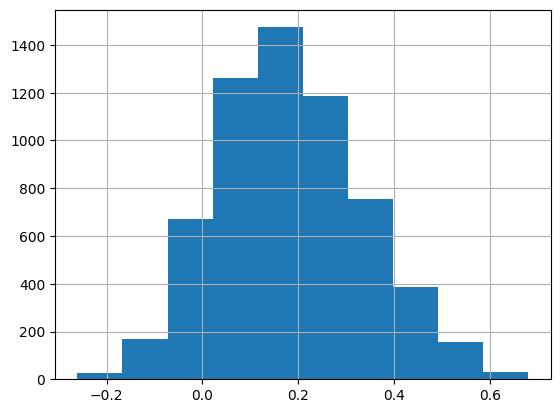

In [189]:
hist = cosine_similarity_dataframe("last", 0, models, intervals).iloc[:,-1].hist()

Now possible to store the full time series of the cosine similarity between the embedding of a word in each time interval and the embedding of that same word in the reference interval (set to "last"):

In [190]:
intervals

[-650, 150, 500, 1400, 2006]

In [191]:
reference_step = "last"
time_series = list()
reference_interval_index = find_reference_intervals(reference_step, intervals)
time_series_df = pd.DataFrame()
#for w in models[reference_interval_index].wv.index_to_key:
df = cosine_similarity_dataframe(reference_step, reference_interval_index, models, intervals)
time_series_df[df.columns[0]] = df.iloc[:,0]
time_series_df[df.columns[1]] = df.iloc[:,1]
for i in range(len(models)):
    #print(reference_interval_index)
    print("Interval", str(intervals[i]), "with", str(list(intervals)[reference_interval_index]))
    df = cosine_similarity_dataframe(reference_step, i, models, intervals)
    if i != reference_interval_index:
        tmp_df = df.iloc[:,-2:]
        #df.iloc[:,-2:].column[0]
        #print(df.iloc[:,0])
        time_series_df[tmp_df.columns[0]] = tmp_df.iloc[:,0]
        time_series_df[tmp_df.columns[1]] = tmp_df.iloc[:,1]
        col_i = "interval-"+str(i)
        time_series_df[col_i] = [i for w in models[reference_interval_index].wv.index_to_key]
        #Finding top 10 nearest neighbours:
        col_n = "neighbours_t"+str(i)
        time_series_df[col_n] = [models[i].wv.similar_by_word(w, 10) for w in models[i].wv.index_to_key]
        #print(time_series_df)
    else:
        tmp_df = df.iloc[:,-2:]
        #df.iloc[:,-2:].column[0]
        #print(df.iloc[:,0])
        time_series_df[tmp_df.columns[0]] = tmp_df.iloc[:,0]
        time_series_df[tmp_df.columns[1]] = tmp_df.iloc[:,1]
        col_i = "interval-"+str(i)
        time_series_df[col_i] = [i for w in models[reference_interval_index].wv.index_to_key]
        #Finding top 10 nearest neighbours:
        col_n = "neighbours_t"+str(i)
        time_series_df[col_n] = [models[i].wv.similar_by_word(w, 10) for w in models[i].wv.index_to_key]
    
time_series_df

Interval -650 with 1400
Interval 150 with 1400
Interval 500 with 1400
Interval 1400 with 1400


,Word,Frequency_t_reference-last,Frequency_t0,"Cosine_similarity(w_t_reference-last,w_t0)",interval-0,neighbours_t0,Frequency_t1,"Cosine_similarity(w_t_reference-last,w_t1)",interval-1,neighbours_t1,Frequency_t2,"Cosine_similarity(w_t_reference-last,w_t2)",interval-2,neighbours_t2,Frequency_t3,"Cosine_similarity(w_t_reference-last,w_t3)",interval-3,neighbours_t3
0,et,54029,118034,0.058036,0,"[(atque, 0.7087029218673706), (que, 0.70040971...",99547,0.057303,1,"[(cumque, 0.5415673851966858), (coram, 0.49242...",111496,0.192296,2,"[(atque, 0.4552074670791626), (autem, 0.449797...",54029,1,3,"[(sicut, 0.49205416440963745), (autem, 0.49122..."
1,sum,45116,96157,0.027151,0,"[(habeo, 0.5969561338424683), (fio, 0.55880624...",61678,0.018352,1,"[(intersum, 0.5156670808792114), (appareo, 0.5...",109417,0.415808,2,"[(existo, 0.5513516068458557), (consisto, 0.52...",45116,1,3,"[(inuenio, 0.47353190183639526), (habeo, 0.454..."
2,qui,41796,95129,0.215450,0,"[(quod, 0.6396672129631042), (quia, 0.53360706...",56013,0.204937,1,"[(quia, 0.5096613168716431), (quoniam, 0.50373...",87296,0.434317,2,"[(quod, 0.6495525240898132), (quia, 0.63505113...",41796,1,3,"[(quicumque, 0.4721740484237671), (quod, 0.449..."
3,in,41081,67844,0.077785,0,"[(ex, 0.4794599115848541), (occupo, 0.46450427...",48810,0.158362,1,"[(extra, 0.45094364881515503), (iuxta, 0.44415...",67147,0.406710,2,"[(circa, 0.4769701063632965), (super, 0.456572...",41081,1,3,"[(extra, 0.46657565236091614), (e, 0.433365136..."
4,is,21897,66081,0.105283,0,"[(et, 0.7004096508026123), (atque, 0.609159708...",30808,0.078124,1,"[(quisque, 0.4708693325519562), (Cumque, 0.423...",50044,0.398968,2,"[(ipse, 0.6091796159744263), (suus, 0.52102297...",21897,1,3,"[(semetipse, 0.5023294687271118), (Iudaei, 0.4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6110,castigatio,21,43,0.529007,0,"[(Papa, 0.6715770363807678), (Solus, 0.6622950...",28,0.517019,1,"[(quominus, 0.6706798672676086), (ingeniosus, ...",38,0.492101,2,"[(flauus, 0.7558671832084656), (crista, 0.7525...",21,1,3,"[(uenenatus, 0.8472064137458801), (depulsus, 0..."
6111,fulcrum,21,43,0.221478,0,"[(XI, 0.7559379935264587), (UII, 0.74267226457...",28,0.327203,1,"[(quattuordecim, 0.8525821566581726), (XIV, 0....",38,0.470319,2,"[(scintilla, 0.6144822835922241), (decerpo, 0....",21,1,3,"[(excurro, 0.8944569230079651), (piscina, 0.88..."
6112,torquis,21,43,0.312981,0,"[(unanimis, 0.5250840783119202), (regulus, 0.4...",28,0.543013,1,"[(remigium, 0.7334339618682861), (torquis, 0.7...",38,0.475974,2,"[(g, 0.692804217338562), (Gherardesca, 0.67727...",21,1,3,"[(pinus, 0.870940625667572), (tyrius, 0.859168..."
6113,utilior,21,43,0.394131,0,"[(iactantia, 0.6297705769538879), (impotentia,...",28,0.576231,1,"[(Nonnullus, 0.7916091680526733), (DE, 0.78360...",38,0.566804,2,"[(acrus, 0.7995414733886719), (gelu, 0.7815071...",21,1,3,"[(propensus, 0.7412359118461609), (demonstrati..."


In [192]:
models

Print to a file:

In [193]:
time_series_df.to_csv(os.path.join(dir_out, 'semantic_change_allwords.csv'), index=None)

In [194]:
time_series_df.columns

Index(['Word', 'Frequency_t_reference-last', 'Frequency_t0',
       'Cosine_similarity(w_t_reference-last,w_t0)', 'interval-0',
       'neighbours_t0', 'Frequency_t1',
       'Cosine_similarity(w_t_reference-last,w_t1)', 'interval-1',
       'neighbours_t1', 'Frequency_t2',
       'Cosine_similarity(w_t_reference-last,w_t2)', 'interval-2',
       'neighbours_t2', 'Frequency_t3',
       'Cosine_similarity(w_t_reference-last,w_t3)', 'interval-3',
       'neighbours_t3'],
      dtype='object')

In [195]:
time_series_df[['interval-0', 'Cosine_similarity(w_t_reference-last,w_t0)']]

,interval-0,"Cosine_similarity(w_t_reference-last,w_t0)"
0,0,0.058036
1,0,0.027151
2,0,0.215450
3,0,0.077785
4,0,0.105283
...,...,...
6110,0,0.529007
6111,0,0.221478
6112,0,0.312981
6113,0,0.394131


In [196]:
time_series_df[['Cosine_similarity(w_t_reference-last,w_t0)',
                           'Cosine_similarity(w_t_reference-last,w_t1)'
               ]].iloc[0]

Cosine_similarity(w_t_reference-last,w_t0)    0.058036
Cosine_similarity(w_t_reference-last,w_t1)    0.057303
Name: 0, dtype: float64

In [197]:
px.line(time_series_df[['interval-0', 'Cosine_similarity(w_t_reference-last,w_t0)']], 
        x = 'interval-0', y = 'Cosine_similarity(w_t_reference-last,w_t0)')

QUESTION: Need help making sure I understand these graphs (and esp their purpose...)

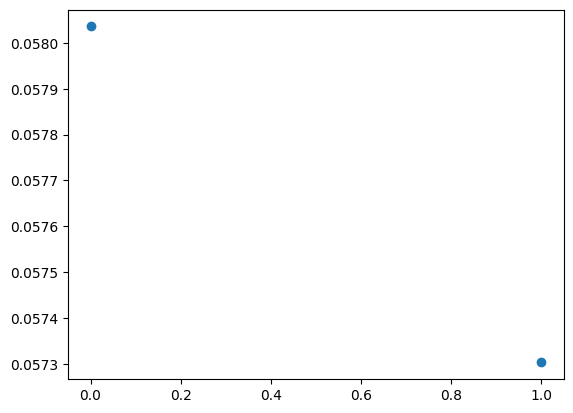

In [198]:
plt.scatter([0,1], 
            time_series_df[['Cosine_similarity(w_t_reference-last,w_t0)',
                           'Cosine_similarity(w_t_reference-last,w_t1)'
                           ]].iloc[0])
plt.show()

Rearrange the dataframe for visualization:

In [199]:
time_series_df.columns

Index(['Word', 'Frequency_t_reference-last', 'Frequency_t0',
       'Cosine_similarity(w_t_reference-last,w_t0)', 'interval-0',
       'neighbours_t0', 'Frequency_t1',
       'Cosine_similarity(w_t_reference-last,w_t1)', 'interval-1',
       'neighbours_t1', 'Frequency_t2',
       'Cosine_similarity(w_t_reference-last,w_t2)', 'interval-2',
       'neighbours_t2', 'Frequency_t3',
       'Cosine_similarity(w_t_reference-last,w_t3)', 'interval-3',
       'neighbours_t3'],
      dtype='object')

In [200]:
time_series_df

,Word,Frequency_t_reference-last,Frequency_t0,"Cosine_similarity(w_t_reference-last,w_t0)",interval-0,neighbours_t0,Frequency_t1,"Cosine_similarity(w_t_reference-last,w_t1)",interval-1,neighbours_t1,Frequency_t2,"Cosine_similarity(w_t_reference-last,w_t2)",interval-2,neighbours_t2,Frequency_t3,"Cosine_similarity(w_t_reference-last,w_t3)",interval-3,neighbours_t3
0,et,54029,118034,0.058036,0,"[(atque, 0.7087029218673706), (que, 0.70040971...",99547,0.057303,1,"[(cumque, 0.5415673851966858), (coram, 0.49242...",111496,0.192296,2,"[(atque, 0.4552074670791626), (autem, 0.449797...",54029,1,3,"[(sicut, 0.49205416440963745), (autem, 0.49122..."
1,sum,45116,96157,0.027151,0,"[(habeo, 0.5969561338424683), (fio, 0.55880624...",61678,0.018352,1,"[(intersum, 0.5156670808792114), (appareo, 0.5...",109417,0.415808,2,"[(existo, 0.5513516068458557), (consisto, 0.52...",45116,1,3,"[(inuenio, 0.47353190183639526), (habeo, 0.454..."
2,qui,41796,95129,0.215450,0,"[(quod, 0.6396672129631042), (quia, 0.53360706...",56013,0.204937,1,"[(quia, 0.5096613168716431), (quoniam, 0.50373...",87296,0.434317,2,"[(quod, 0.6495525240898132), (quia, 0.63505113...",41796,1,3,"[(quicumque, 0.4721740484237671), (quod, 0.449..."
3,in,41081,67844,0.077785,0,"[(ex, 0.4794599115848541), (occupo, 0.46450427...",48810,0.158362,1,"[(extra, 0.45094364881515503), (iuxta, 0.44415...",67147,0.406710,2,"[(circa, 0.4769701063632965), (super, 0.456572...",41081,1,3,"[(extra, 0.46657565236091614), (e, 0.433365136..."
4,is,21897,66081,0.105283,0,"[(et, 0.7004096508026123), (atque, 0.609159708...",30808,0.078124,1,"[(quisque, 0.4708693325519562), (Cumque, 0.423...",50044,0.398968,2,"[(ipse, 0.6091796159744263), (suus, 0.52102297...",21897,1,3,"[(semetipse, 0.5023294687271118), (Iudaei, 0.4..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6110,castigatio,21,43,0.529007,0,"[(Papa, 0.6715770363807678), (Solus, 0.6622950...",28,0.517019,1,"[(quominus, 0.6706798672676086), (ingeniosus, ...",38,0.492101,2,"[(flauus, 0.7558671832084656), (crista, 0.7525...",21,1,3,"[(uenenatus, 0.8472064137458801), (depulsus, 0..."
6111,fulcrum,21,43,0.221478,0,"[(XI, 0.7559379935264587), (UII, 0.74267226457...",28,0.327203,1,"[(quattuordecim, 0.8525821566581726), (XIV, 0....",38,0.470319,2,"[(scintilla, 0.6144822835922241), (decerpo, 0....",21,1,3,"[(excurro, 0.8944569230079651), (piscina, 0.88..."
6112,torquis,21,43,0.312981,0,"[(unanimis, 0.5250840783119202), (regulus, 0.4...",28,0.543013,1,"[(remigium, 0.7334339618682861), (torquis, 0.7...",38,0.475974,2,"[(g, 0.692804217338562), (Gherardesca, 0.67727...",21,1,3,"[(pinus, 0.870940625667572), (tyrius, 0.859168..."
6113,utilior,21,43,0.394131,0,"[(iactantia, 0.6297705769538879), (impotentia,...",28,0.576231,1,"[(Nonnullus, 0.7916091680526733), (DE, 0.78360...",38,0.566804,2,"[(acrus, 0.7995414733886719), (gelu, 0.7815071...",21,1,3,"[(propensus, 0.7412359118461609), (demonstrati..."


In [201]:
time_series_df1 = pd.DataFrame()
for index, row in time_series_df.iterrows():
    #print(row['interval-0'], row['Cosine_similarity(w_t_reference-last,w_t0)'])
    
    #temp = pd.DataFrame(
    #    {
    #        'Time_interval': row['interval-0'],
    #        'Cosine_sim': row['Cosine_similarity(w_t_reference-last,w_t0)'],
    #        'Word': row['Word']
    #    }
    #)
    #print([row['interval-0'],row['Cosine_similarity(w_t_reference-last,w_t0)'],row['Word']])
    #print(pd.DataFrame(
    #    [row['interval-0'],row['Cosine_similarity(w_t_reference-last,w_t0)'],row['Word']]))
    time_series_df1 = pd.concat([time_series_df1, pd.DataFrame(
        [row['interval-0'],row['Cosine_similarity(w_t_reference-last,w_t0)'],row['Word']]).transpose()])
    time_series_df1 = pd.concat([time_series_df1, pd.DataFrame(
        [row['interval-1'],row['Cosine_similarity(w_t_reference-last,w_t1)'],row['Word']]).transpose()])
    #print(time_series_df1)

time_series_df1.columns = ['Time_interval', 'Cosine_sim', 'Word']
time_series_df1

,Time_interval,Cosine_sim,Word
0,0,0.058036,et
0,1,0.057303,et
0,0,0.027151,sum
0,1,0.018352,sum
0,0,0.21545,qui
...,...,...,...
0,1,0.543013,torquis
0,0,0.394131,utilior
0,1,0.576231,utilior
0,0,0.600941,inclemens


Print to output file:

In [ ]:
time_series_df1.to_csv(os.path.join(dir_out, 'semantic_change1_allwords.csv'), index=None) 

List of NeoLatin terms:

In [202]:
neolatin_terms = ["torcular", "humanitas", "traduco", "machina","commentarius", "pastor", "specillum", "spatula", "sphatula", "lenticula", "scando", "feretrum", "ferculum", "catheter", "operator", "operatio", "examino", "discus", "cannula", "acus", "syringa", "fistula", "monitor", "prothesis", "iniectio", "civis", "patria", "natio", "populus", "democratia", "satrapa", "toparcha", "sacerdos", "sacerdotulus", "sacrificulus", "papicolae", "lutheromastix", "capniomastix", "elater", "elasticitas", "electricitas", "machina", "carina", "catapulta", "tormentum", "sclopus", "legio", "phalanx"]

In [203]:
time_series_df_neol = time_series_df[time_series_df['Word'].isin(neolatin_terms)]
time_series_df_neol.to_csv(os.path.join(dir_out, 'semantic_change_neolwords.csv'), index=None) 
time_series_df_neol

,Word,Frequency_t_reference-last,Frequency_t0,"Cosine_similarity(w_t_reference-last,w_t0)",interval-0,neighbours_t0,Frequency_t1,"Cosine_similarity(w_t_reference-last,w_t1)",interval-1,neighbours_t1,Frequency_t2,"Cosine_similarity(w_t_reference-last,w_t2)",interval-2,neighbours_t2,Frequency_t3,"Cosine_similarity(w_t_reference-last,w_t3)",interval-3,neighbours_t3
91,populus,2047,4725,0.096516,0,"[(uox, 0.6349189281463623), (oratio, 0.5751495...",2679,0.047878,1,"[(sermo, 0.8077818751335144), (scriptura, 0.58...",3964,0.225514,2,"[(etiamsi, 0.4603976309299469), (si, 0.4570612...",2047,1,3,"[(plebs, 0.6392802596092224), (gens, 0.5644101..."
265,sacerdos,768,1851,0.163320,0,"[(magnus, 0.6639509797096252), (maximus, 0.556...",1024,0.115418,1,"[(maximus, 0.53492271900177), (magnus, 0.52971...",1511,0.234748,2,"[(interrogo, 0.713268518447876), (loquor, 0.62...",768,1,3,"[(minister, 0.7088908553123474), (fidelis, 0.5..."
443,patria,516,1208,-0.198625,0,"[(sacer, 0.7659971117973328), (sacrificium, 0....",655,-0.222875,1,"[(pontifex, 0.7035117149353027), (scriba, 0.63...",989,0.149105,2,"[(enim, 0.7518006563186646), (namque, 0.720122...",516,1,3,"[(faio, 0.6693706512451172), (ciuis, 0.6616998..."
946,pastor,250,563,0.302158,0,"[(foueo, 0.7006201148033142), (senilis, 0.6502...",319,0.043554,1,"[(eleuo, 0.7538178563117981), (extendo, 0.7256...",459,0.316797,2,"[(mixtus, 0.7405639290809631), (commisceo, 0.7...",250,1,3,"[(Pastor, 0.741081953048706), (seruitium, 0.67..."
1000,legio,238,532,0.054854,0,"[(quinquaginta, 0.9090250730514526), (quadragi...",308,0.137271,1,"[(sexaginta, 0.9266019463539124), (triginta, 0...",434,0.433002,2,"[(trepidus, 0.7739681005477905), (deicio, 0.76...",238,1,3,"[(equitatus, 0.8919309973716736), (nauigium, 0..."
1236,natio,191,427,0.113861,0,"[(uolucer, 0.7220849990844727), (uacca, 0.6976...",247,0.011901,1,"[(lupus, 0.7533623576164246), (uolucer, 0.7455...",342,0.274518,2,"[(iacto, 0.6545971035957336), (domo, 0.6474092...",191,1,3,"[(regio, 0.7698048949241638), (prouincia, 0.69..."
1501,tormentum,152,337,0.290957,0,"[(exspecto, 0.7298107743263245), (opperior, 0....",200,0.286950,1,"[(exspecto, 0.6770321726799011), (praeuenio, 0...",277,0.094089,2,"[(sapio, 0.7808188796043396), (prudens, 0.7318...",152,1,3,"[(agmen, 0.8034407496452332), (nauigium, 0.792..."
1577,humanitas,143,319,0.187560,0,"[(abnuo, 0.6298038363456726), (desisto, 0.6189...",190,0.315155,1,"[(denego, 0.6645423769950867), (indignus, 0.66...",264,0.053188,2,"[(ignobilis, 0.5947808027267456), (ualde, 0.58...",143,1,3,"[(modestia, 0.7572274804115295), (pietas, 0.73..."
1936,machina,112,247,0.230010,0,"[(fatigo, 0.6853361129760742), (destituo, 0.63...",148,0.189241,1,"[(praecaueo, 0.6380741596221924), (subtraho, 0...",207,0.060551,2,"[(patrimonium, 0.6232470870018005), (hereditas...",112,1,3,"[(saucius, 0.7872088551521301), (ruina, 0.7838..."
3079,examino,60,130,0.152112,0,"[(mancipium, 0.6567324995994568), (auarus, 0.6...",82,0.245071,1,"[(creditor, 0.8589144349098206), (debitor, 0.7...",109,0.264153,2,"[(progredior, 0.8068349361419678), (nauigo, 0....",60,1,3,"[(exquiro, 0.7719724774360657), (perpendo, 0.7..."


In [204]:
time_series_df1_neol = time_series_df1[time_series_df1['Word'].isin(neolatin_terms)]
time_series_df1_neol.to_csv(os.path.join(dir_out, 'semantic_change1_neolwords.csv'), index=None) 
time_series_df1_neol

,Time_interval,Cosine_sim,Word
0,0,0.096516,populus
0,1,0.047878,populus
0,0,0.16332,sacerdos
0,1,0.115418,sacerdos
0,0,-0.198625,patria
0,1,-0.222875,patria
0,0,0.302158,pastor
0,1,0.043554,pastor
0,0,0.054854,legio
0,1,0.137271,legio


In [205]:
time_series_df1_neol.dtypes

Time_interval    object
Cosine_sim       object
Word             object
dtype: object

In [ ]:
time_series_df1_neol["Time_interval"] = pd.to_numeric(time_series_df1_neol["Time_interval"], downcast='integer')

/var/folders/3d/s1l2k39n20xf5qg589sk0yhw0000gp/T/ipykernel_33936/1858834944.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
time_series_df1_neol["Cosine_sim"] = pd.to_numeric(time_series_df1_neol["Cosine_sim"], downcast='float')

/var/folders/3d/s1l2k39n20xf5qg589sk0yhw0000gp/T/ipykernel_33936/1038798913.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



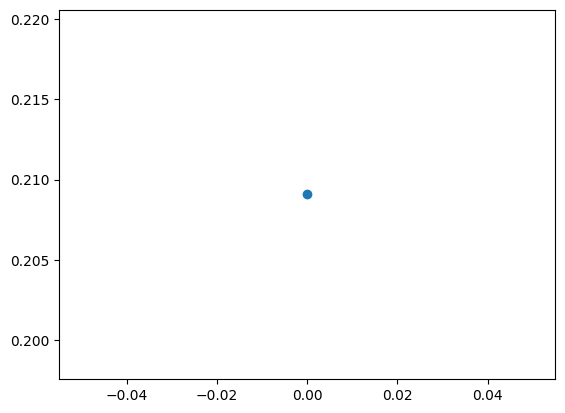

In [ ]:
for i in range(len(neolatin_terms)):
    plt.scatter(time_series_df1_neol[['Time_interval']].iloc[i], 
            time_series_df1_neol[['Cosine_sim']].iloc[i])
plt.show()

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/valentinalunardi/Library/Python/3.9/lib/python/site-p

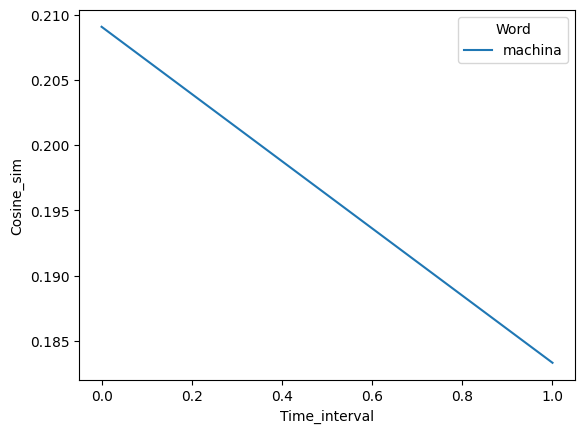

In [ ]:
import seaborn as sns
#sns.lmplot('Time_interval', 'Cosine_sim', data=time_series_df1_chr, hue='Word', fit_reg=False)
sns.lineplot(x='Time_interval', y='Cosine_sim', data=time_series_df1_neol, hue='Word', legend="full")
plt.show()

QUESTION: Once again, help with graph interepretation!!